In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import BING_BONG, FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation
from Batoid4LOFT import Pearl

from psd_utils import PSDUtils

from scipy.optimize import minimize, Bounds

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import pdpr, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Tue Jul 21 13:38:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             65W /  300W |   12443MiB /  81920MiB |     10%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [2]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sys = telescope(config=config, optic_opd_data=optic_opd_data)

In [3]:
# detector_data = utils.load_pickle('/home/derbyk/src/ffpr/data/detector_data.pkl')
# platescale = 4.486 # arcsec/mm

# w = 36 * platescale / 60
# h = 24 * platescale / 60
# w_offset = w / 2
# h_offset = h / 2

# positions = [(data['xy'][0] + w_offset, data['xy'][1] + h_offset) for data in detector_data]
# mags = (np.ones(len(positions)) * 18).tolist()

# sys.set_source_parameters(magnitudes=mags, positions=positions)

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

for i, im in enumerate(images):
    print(f'Image {i + 1:02.0f} SNR = {im.max() / dark.std():.1f}')

Image 01 SNR = 624.8
Image 02 SNR = 1016.5
Image 03 SNR = 547.4
Image 04 SNR = 1238.6
Image 05 SNR = 737.7
Image 06 SNR = 685.4
Image 07 SNR = 1194.2


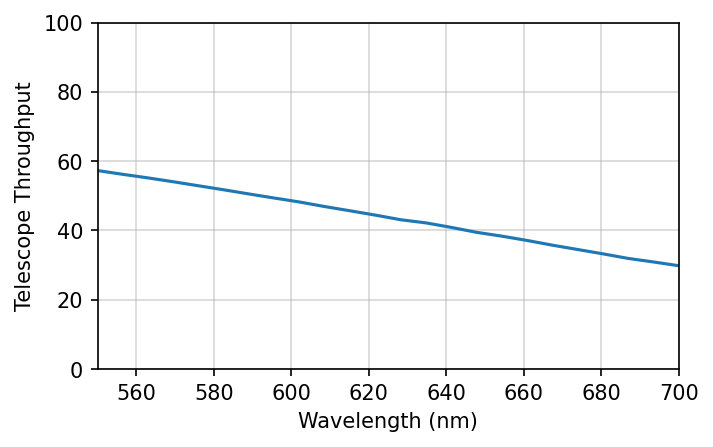

In [7]:
plt.figure(figsize=(5, 3), dpi=150)
plt.plot(sys.wvls.get() * 1000, sys.throughput.get() * 100)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Telescope Throughput')
plt.ylim([0, 100])
plt.xlim([sys.wvls.min().get() * 1000, sys.wvls.max().get() * 1000])
plt.grid(which='both', alpha=0.5)

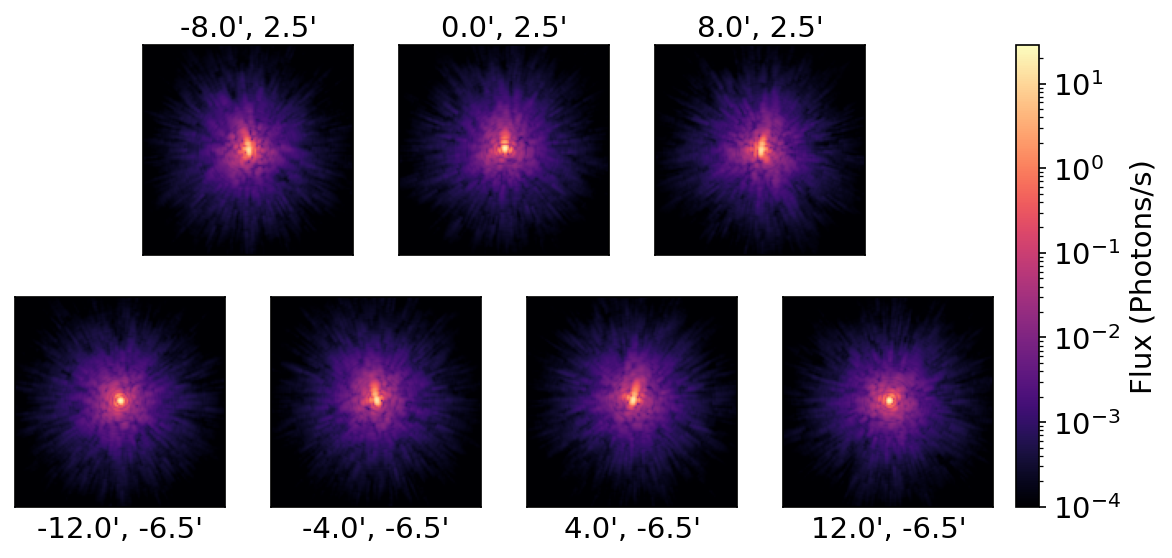

In [ ]:
_, fluxes = sys.snap(stacked_frames=1, debug=True)

pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_fluxes_7(psfs=fluxes, fields=fields)

## PSFS

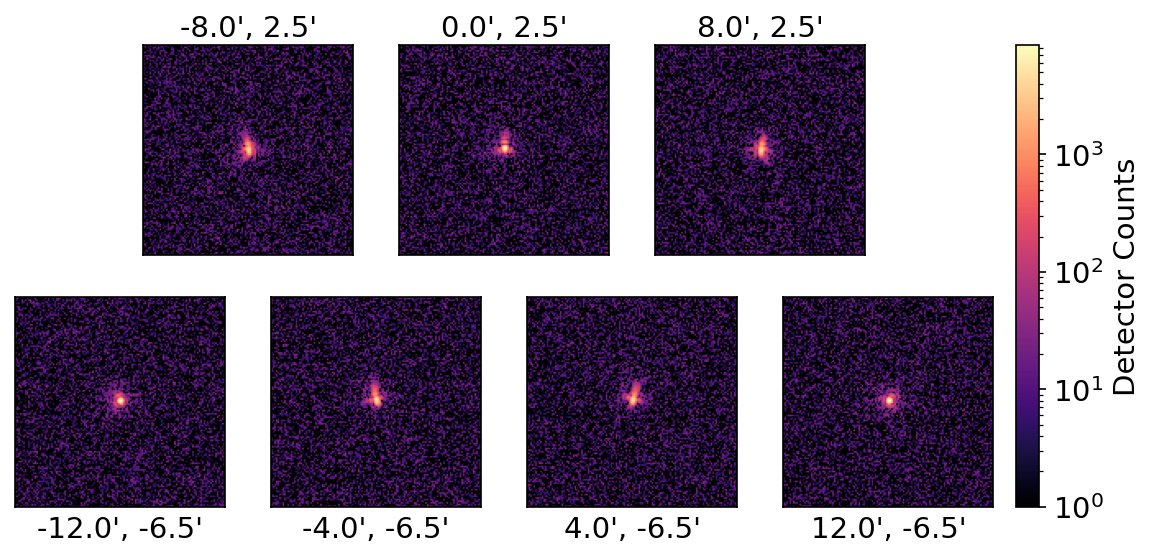

In [5]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## WFES

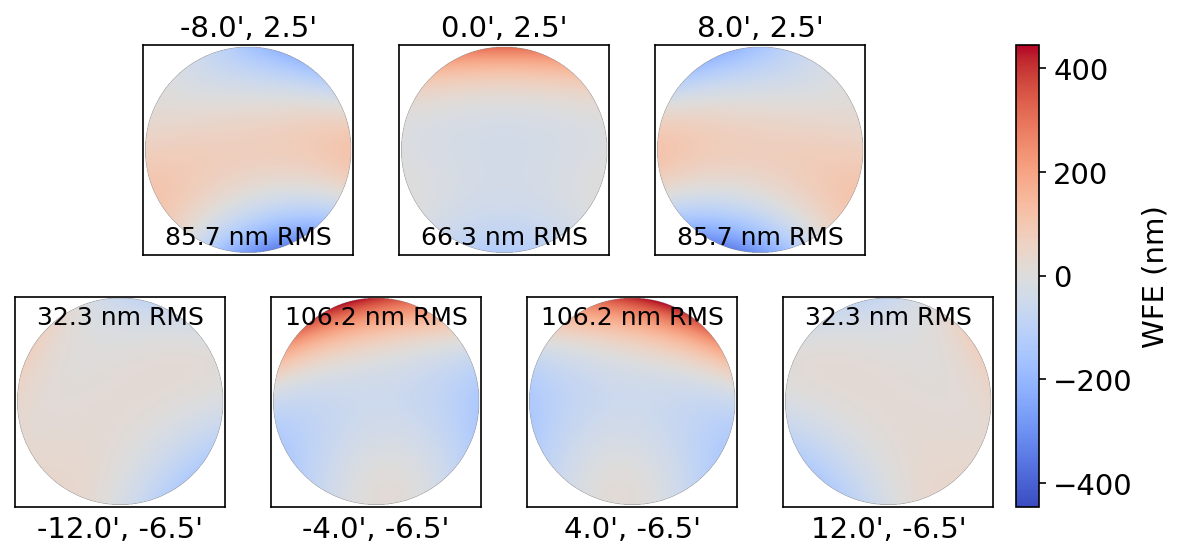

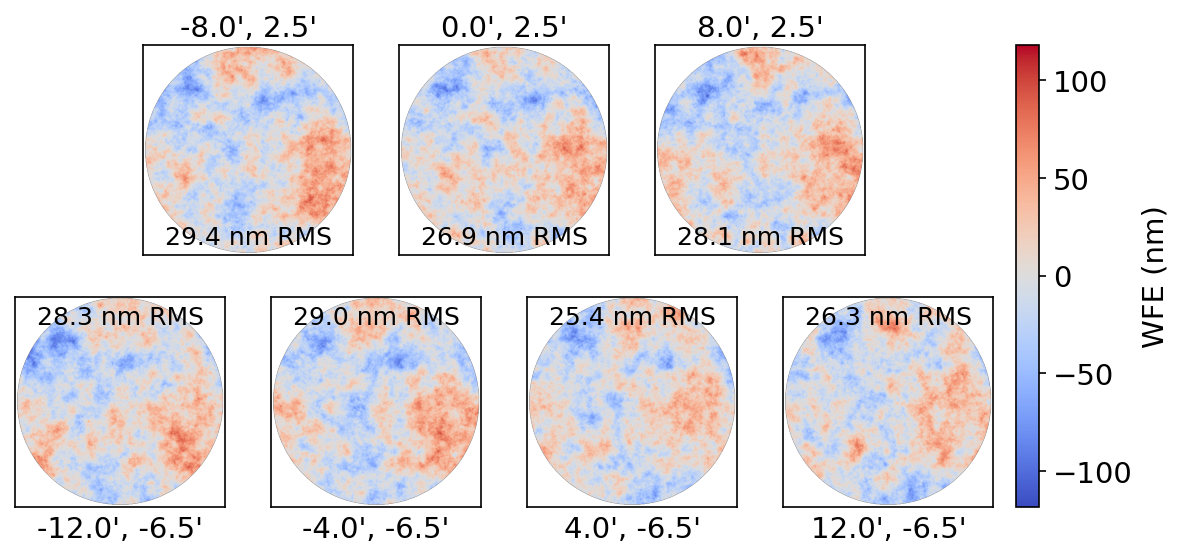

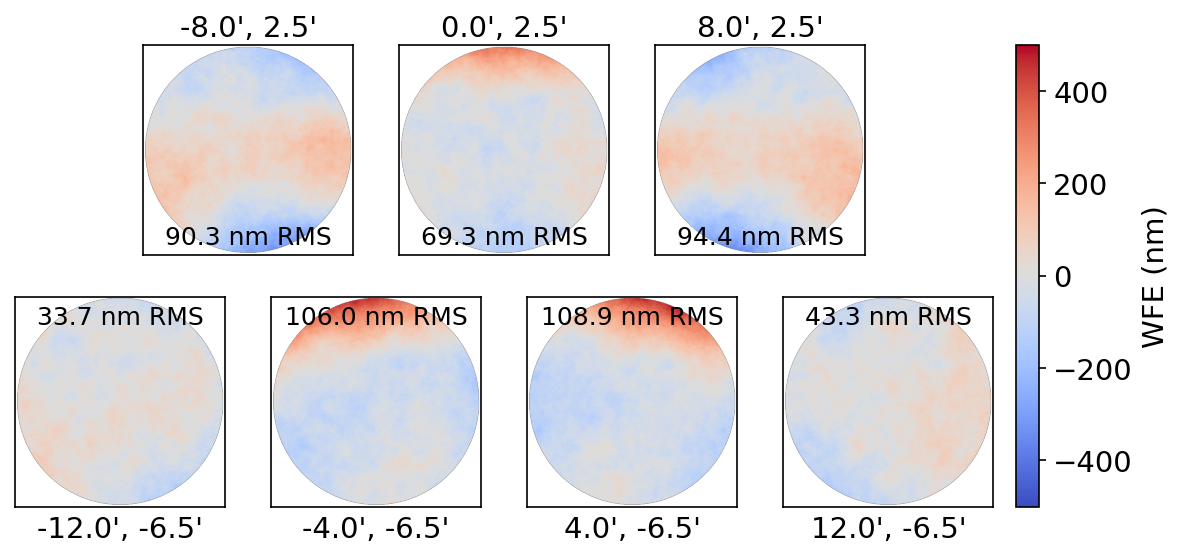

In [6]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

opds_fields_nominal = opds_fields

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

## MISALIGN

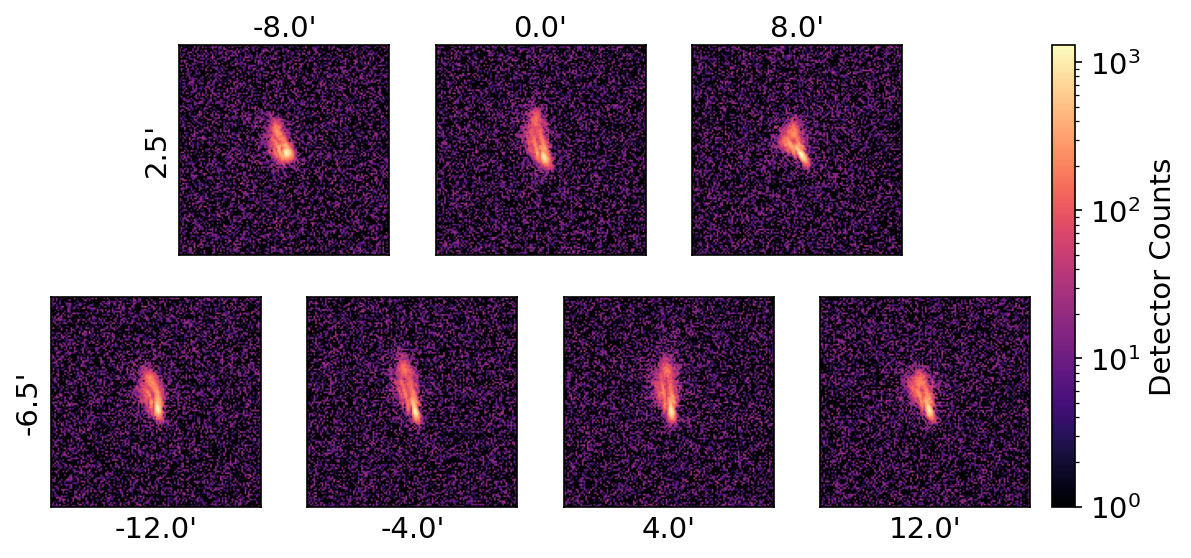

In [7]:
misalignments = utils.load_pickle('/home/derbyk/src/ffpr/data/misalignments_cases_100_dec_50um_tilt_5as.pkl')
m = misalignments[2]

sys.move_optics(M1_motion=m['M1'], M2_motion=m['M4'], M3_motion=m['M4'], M4_motion=m['M4'])

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

utils.plot_psfs_7(psfs=images, fields=fields)

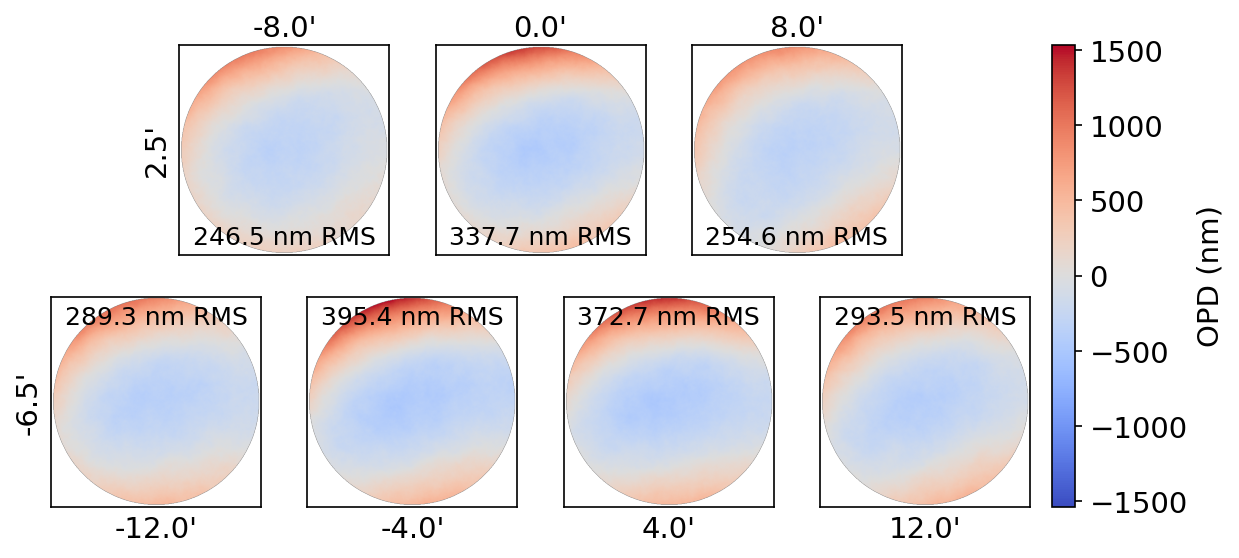

In [8]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

In [71]:
amp = sys.pupil

x, y = make_xy_grid(shape=amp.shape, diameter=2 / 0.98)
r_norm, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(1, 50)]
zernikes = list(zernike_nm_seq(nms, r_norm, t, norm=True))

# for some reason, how the basis is normalized REALLY matters
# having everything normalized to unit peak-to-valley works best
# zernikes = [z - np.min(z[amp]) for z in zernikes]
# zernikes = [z / np.max(z[amp]) for z in zernikes]
# zernikes = [z - 0.5 for z in zernikes]

coeffs = lstsq(zernikes, opds_truths[1])

display(coeffs)

array([191.47379718, -48.35655429,  77.14437252, 101.2745583 ,
       -84.34787402, -72.31641751,  26.11507215, -14.93132499,
       -34.03678203,  -2.19911416, -22.77160692,  -5.90637425,
        15.24199786,  19.53130646,  -0.53567792,   8.04994998,
       -11.82981853,  -5.60123477,  -1.17953182,  -3.97153744,
         7.21437248, -14.10375825,   7.47345723,   8.16024263,
        -0.21330522,   5.35002469,  -4.27679183,  -8.89952929,
        -4.51157381,   3.89361588,   4.66094089,   5.31531131,
        -2.4148459 ,   2.16694975,  -3.91891417,   0.20439519,
        -0.3080817 ,  -0.73772162,  -0.97902364,  -4.65221386,
         0.33900767,   0.87079561,   2.08153883,   4.11829243,
         1.31282683,  -0.71480359,   0.90505073,  -0.70540421,
        -0.73629065])

## FFPR

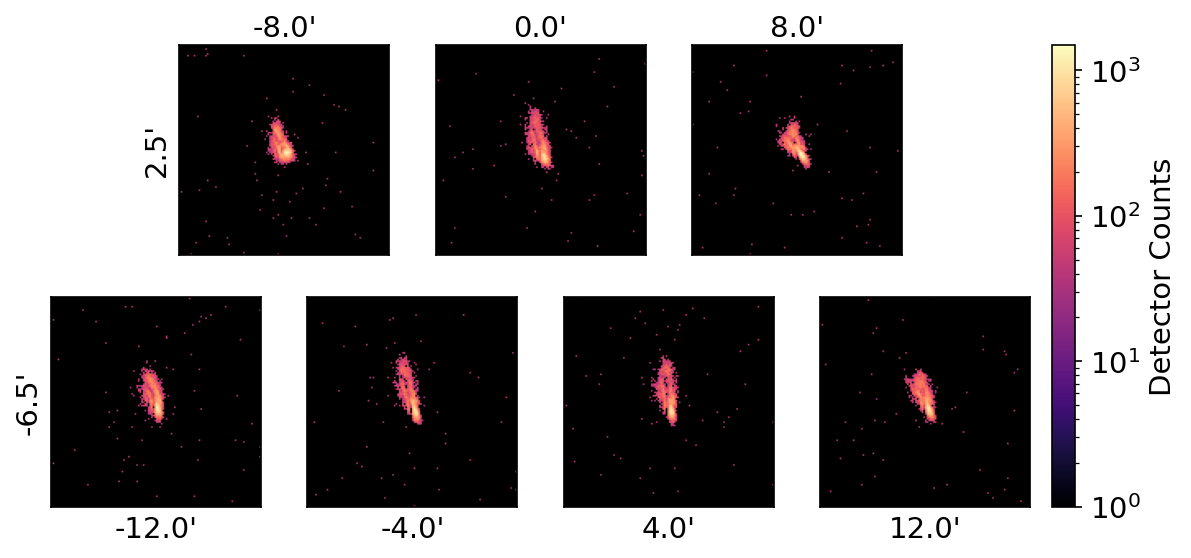

In [9]:
dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

snr_thresh = 5
noise_lvl = dark.std()

masks = []

for im in images:
    mask = im > noise_lvl * snr_thresh
    masks.append(mask)

utils.plot_psfs_7(psfs=[i * m for i, m in zip(images, masks)], fields=fields)

In [10]:
efl = sys.cfg['general']['f_eff']
pupil_dx = sys.cfg['optics']['m1']['diam'] / sys.cfg['general']['npix_pupil']
focal_dx = sys.cfg['detector']['dx_focal']

opt = FFPR2(wvls=sys.wvls.tolist(), amp=sys.pupil, max_zernike=11, fields=fields, divs=opds_fields_nominal, efl=efl, 
            psfs=images, pupil_dx=pupil_dx, focal_dx=focal_dx, error=gain_invariant_error, masks=masks, jitter_kernel=sys.jitter_kernel)

BING_BONG(opt=opt, modal_cleanup=True, zonal_cleanup=False,
          max_kicks=10, iter_per_bing_bong=10, iter_per_psf=10,
          max_ls=10, thresh_conv=1e-1, frac_conv=5e-2)

INITIALIZE BING BONG
---------------
BING 01 | f = 4.36e-01
BONG 01 | f = 4.19e-01
STUCK ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 02 | f = 3.99e-01
BONG 02 | f = 3.89e-01
STUCK ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 03 | f = 1.85e-01
BONG 03 | f = 1.70e-01
---------------
BING 04 | f = 4.66e-02
BONG 04 | f = 4.61e-02
CONVERGED: BONG WITHIN  5% OF BING, f BELOW 1.00e-01
TERMINATE BING BONG
---------------
INDIVIDUAL PSF OPTIMIZATION: MODAL
---------------
DONE



/tmp/ipykernel_2353885/473777310.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 1])


(0.023078310914840063, 1)

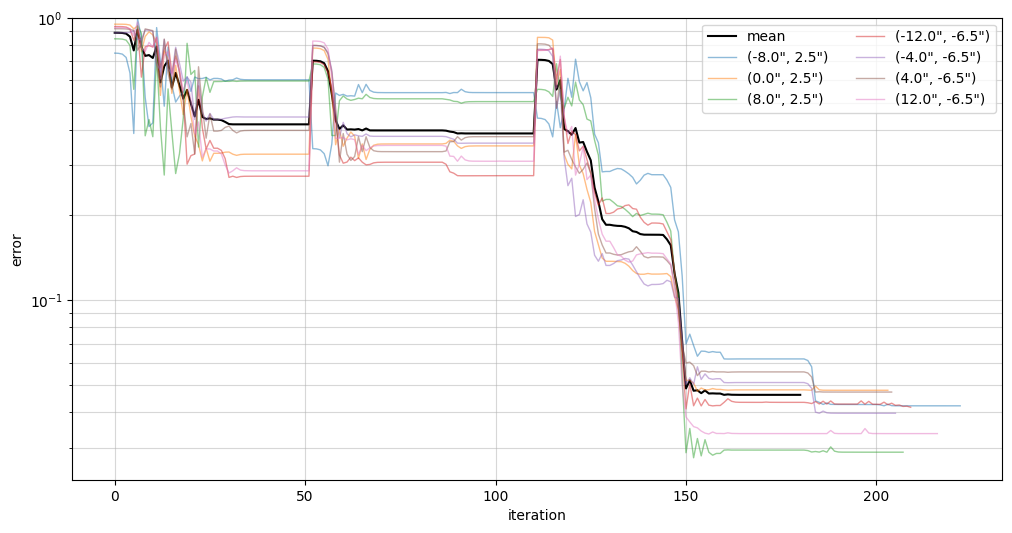

In [11]:
plt.figure(figsize=(12, 6))
plt.semilogy(np.array(opt.costs).get(), label='mean', color='k', linewidth=1.5)
plt.xlabel('iteration')
plt.ylabel('error')
plt.grid(which='both', alpha=0.5)

for pdpr, field in zip(opt.PDPR_list, fields):
    plt.semilogy(np.array(pdpr.costs).get(), label=f'({field[0]:.1f}", {field[1]:.1f}")', alpha=0.5, linewidth=1)

plt.legend(ncols=2)
# plt.xlim([0, len(opt.costs)])
plt.ylim([0, 1])

In [66]:
opds_estimates = [pdpr.models[0].opd + pdpr.models[0].div for pdpr in opt.PDPR_list]

for opd_est, opd_tru in zip(copy.deepcopy(opds_estimates), copy.deepcopy(opds_truths)):
    opd_est[~sys.pupil] = np.nan
    opd_tru[~sys.pupil] = np.nan
    opd_est -= np.nanmean(opd_est)
    opd_tru -= np.nanmean(opd_tru)
    coeffs_est = lstsq(zernikes, opd_est)[2:10]
    coeffs_tru = lstsq(zernikes, opd_tru)[2:10]
    diff1 = np.sqrt(np.mean(np.array([(ce - ct) ** 2 for ce, ct in zip(coeffs_est, coeffs_tru)])))

    oe = sum_of_2d_modes(zernikes[2:10], coeffs_est) * sys.pupil
    ot = sum_of_2d_modes(zernikes[2:10], coeffs_tru) * sys.pupil
    diff2 = np.sqrt(np.mean((oe - ot) ** 2))

    print(diff1)
    print(diff2)


11.03653979684365
5.855275242742014
17.22311434157757
8.220341736151525
13.045223663299225
7.195797805001075
13.159101160824827
6.319799660271409
23.52158730773736
11.260518528625177
16.329965681705822
8.045349836421133
16.314344180858953
8.664221941989144


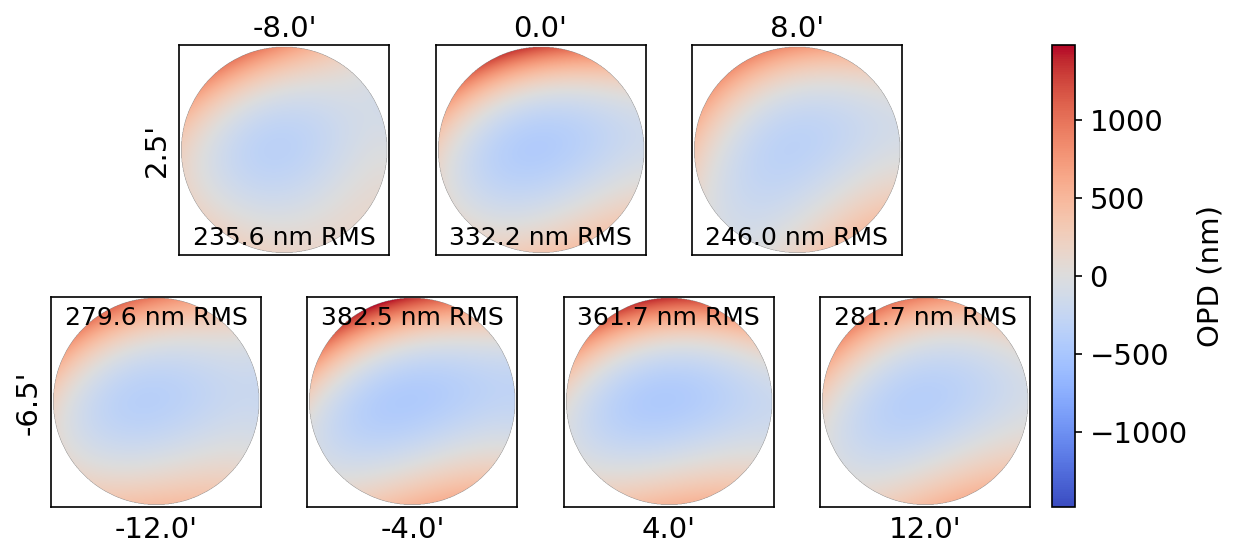

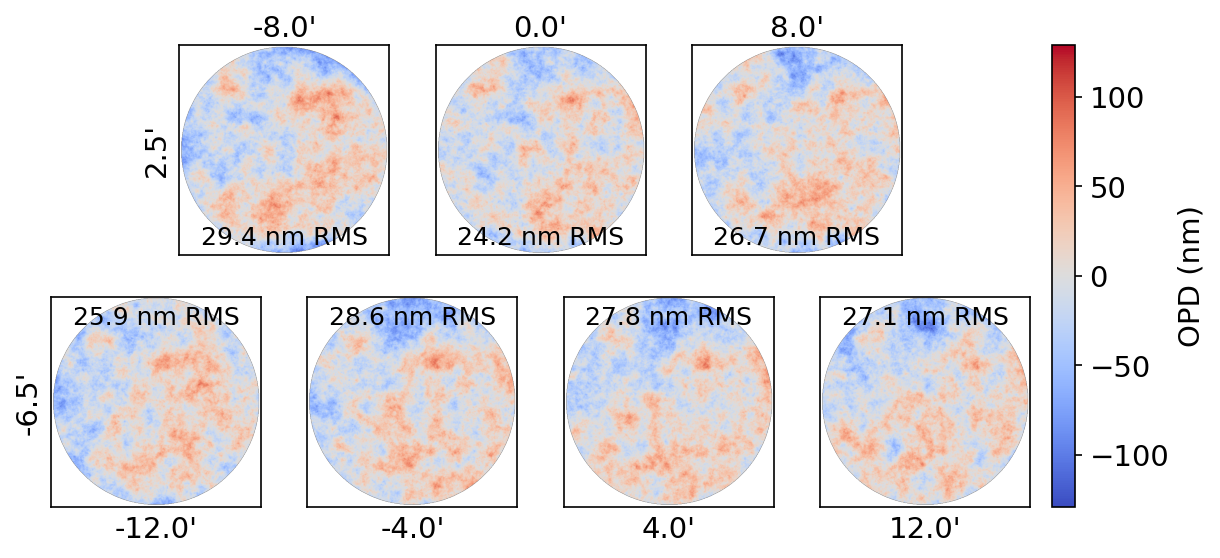

In [12]:
opds_estimates = [pdpr.models[0].opd + pdpr.models[0].div for pdpr in opt.PDPR_list]
opds_residuals = [estimate - truth for estimate, truth, optics in zip(opds_estimates, opds_truths, opds_optics)]

utils.plot_opds_7(opds=opds_estimates, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_residuals, pupil=pupil, fields=fields)

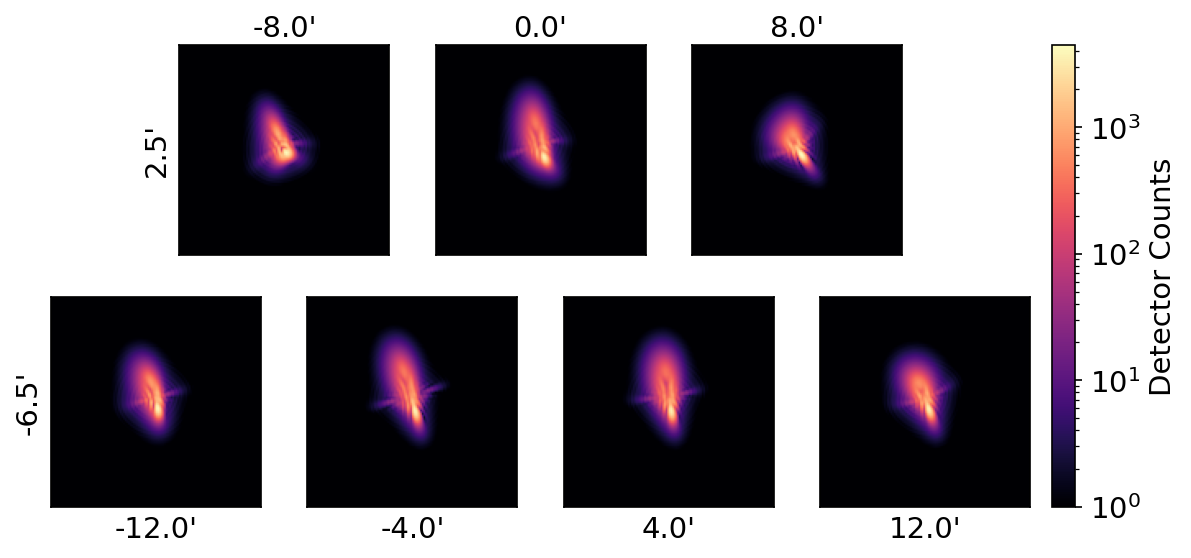

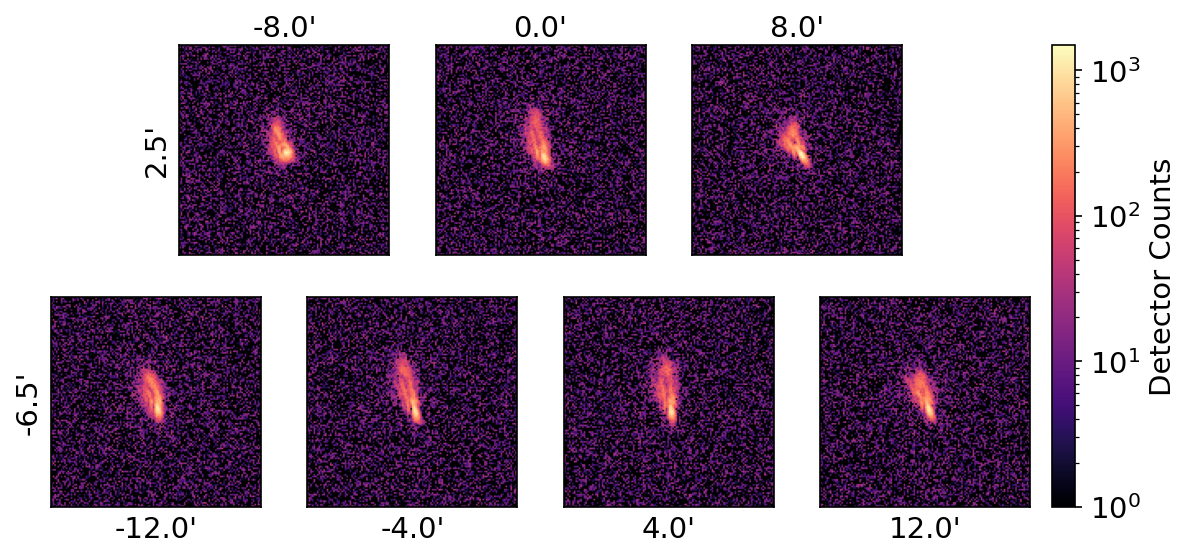

In [13]:
psf_estimates = [pdpr.models[0].I for pdpr in opt.PDPR_list]

psf_truths = [pdpr.models[0].psf for pdpr in opt.PDPR_list]

utils.plot_psfs_7(psfs=psf_estimates, fields=fields)

utils.plot_psfs_7(psfs=psf_truths, fields=fields)